In [1]:
%run utilities_general.ipynb 
%run utilities_DIRKs_and_PIRKs.ipynb
load_standard_packages()
change_wordir()
import json
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
import itertools as it

C:\Users\andre\AppData\Local\Temp\ipykernel_13112\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [2]:
model = "with_dpsi"
# model = "latest_dev"
m = load_model(model)

colors, colours = colourblind_palette("own")


succesfully loaded with_dpsi :D


# read in all those measurements

In [3]:
#file_name = "PIRK_ECS_20250708_Loewenzahn.json"
#file_name = "PIRK_ECS_20250710_rand_leaf_50-2000.json"
#file_name = "PIRK_ECS_20250721_Loewenzahn_500_to_2000.json"
file_name_1 = "PIRK_ECS_20250805_Ocimum_basilicum.json"
file_name_2 = "PIRK_ECS_20250805_Petroselinum_crispum.json"

with open("data/" +file_name_1, 'r') as file:
    json_data1 = json.load(file)

with open("data/" +file_name_2, 'r') as file:
    json_data2 = json.load(file)

In [4]:
print(json_data1)

[{'time': '1754986456922', 'device_name': 'MultispeQ', 'device_version': '2', 'device_id': '11:16:70:15', 'device_battery': 84, 'device_firmware': 2.345, 'sample': [{'time': '1754986456922', 'v_arrays': [[1000, 2500, 2], [15, 2, 15, 2, 20, 2, 40, 2, 80, 2, 160, 2, 320, 2, 320], [30, 40, 50, 60, 70, 85, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]], 'set_repeats': 35, 'protocol_id': '3584', 'set': [{'time': '1754986456939', 'label': 'env', 'autogain': [[1, 10, 1, 20, -461, 49687], [2, 1, 3, 12, -557, 48366], [8, 10, 1, 20, -454, 47865]], 'light_intensity': 0.905, 'r': 29, 'g': 19, 'b': 20, 'w': 34, 'temperature': 28.2, 'humidity': 43.17871, 'pressure': 1013.77435, 'temperature2': 28.55, 'humidity2': 43.99805, 'pressure2': 1013.92767, 'contactless_temp': 28.67, 'compass_direction': 'SE', 'compass': 241.02, 'angle': 2.535, 'pitch': 1.11, 'roll': 2.28, 'data_raw': []}, {'time': '1

protocol indeces: [15, 17, 32, 34, 54, 56, 96, 98, 178, 180, 340, 342, 662, 664, 984]
shortest window length detected: 15
dt = 1.012, 7 relaxation windows fitted for 35 PAR levels.
protocol indeces: [15, 17, 32, 34, 54, 56, 96, 98, 178, 180, 340, 342, 662, 664, 984]
shortest window length detected: 15


dt = 1.012, 7 relaxation windows fitted for 35 PAR levels.


,PAR,time,amplitude,peak_hight,baseline,Tau,rate,flux,r_squared,traces,simulation_meta_info
PAR,,,,,,,,,,,
30,30,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[0.8508621519193572, 0.8280680377159991, 0.938...","[1.197566679468166, 1.1588837521406141, 1.1638...","[0.22030380420773976, 0.6015683263323849, 0.71...","[6.420770038731642, 6.183728713440509, 7.37282...","[0.15574455929238354, 0.16171472688096292, 0.1...","[0.13251715086924937, 0.1339107965580977, 0.12...","[0.9404944913128468, 0.9221697676351369, 0.844...","{'absorbance': [nan, nan, 0.05150315665428668,...","[(15.18, 30), (17.204, 2500), (32.384, 0), (34..."
40,40,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[0.9696191268255069, 1.110074840884702, 1.2396...","[1.1260365849003813, 1.237163597918562, 1.1312...","[0.03710023635206323, 0.2314864074277367, 0.02...","[5.0134496129751245, 4.879549683012459, 10.559...","[0.19946345873546564, 0.20493694397279624, 0.0...","[0.1934035846926777, 0.2274953454719989, 0.117...","[0.9045618280494331, 0.9111092951969452, 0.833...","{'absorbance': [nan, nan, 0.01176312247914227,...","[(15.18, 40), (17.204, 2500), (32.384, 0), (34..."
50,50,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.1247816596086484, 1.0406665958146715, 1.180...","[1.0943184376683597, 1.2535995763978367, 1.266...","[-0.09301750452953168, 0.17054211932085891, 0....","[5.4389810780236765, 4.430627071860333, 7.6519...","[0.18385796634603532, 0.22570168596476337, 0.1...","[0.20680006851896462, 0.2348802052025823, 0.15...","[0.9444929292983734, 0.9009881458450084, 0.935...","{'absorbance': [nan, nan, -0.06611037554992896...","[(15.18, 50), (17.204, 2500), (32.384, 0), (34..."
60,60,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.0187677082226776, 1.1523054354491158, 1.098...","[1.0846603000135007, 1.4207779644932865, 1.226...","[-0.09193266181118002, 0.09721480735926392, -0...","[4.679857171395338, 3.776610868379067, 7.25831...","[0.2136817350136867, 0.26478767202965847, 0.13...","[0.21769205146893908, 0.30511627371969324, 0.1...","[0.941662083435223, 0.888939193412798, 0.83900...","{'absorbance': [nan, nan, -0.03817883105645717...","[(15.18, 60), (17.204, 2500), (32.384, 0), (34..."
70,70,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.2540973777353974, 1.2308798105247667, 1.167...","[1.3452731073200188, 1.0847996963621314, 1.190...","[0.0446775392714799, -0.1008078619531417, -0.0...","[2.6946132978821176, 5.962810786170966, 4.3539...","[0.37111076412558675, 0.16770614327042105, 0.2...","[0.4654090361392779, 0.20642610585253524, 0.26...","[0.9609015394475642, 0.8932671729994546, 0.898...","{'absorbance': [nan, nan, 0.15049832552693393,...","[(15.18, 70), (17.204, 2500), (32.384, 0), (34..."
85,85,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.2644068714888859, 1.3521425366117132, 1.231...","[1.287634190848125, 1.3758299827074367, 1.3756...","[-0.1536846849055822, -0.2527335238504354, -0....","[3.5389542400559435, 5.339286562856629, 5.5060...","[0.28256935019995966, 0.1872909401335783, 0.18...","[0.3572826280649784, 0.2532440468766091, 0.223...","[0.9474198335914742, 0.9440146488452631, 0.921...","{'absorbance': [nan, nan, 0.1490605380371765, ...","[(15.18, 85), (17.204, 2500), (32.384, 0), (34..."
100,100,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.4307609697372934, 1.3909522602626678, 1.262...","[1.0943347378541086, 1.3233702249257793, 1.459...","[-0.28579661263824047, -0.3767329213470972, -0...","[4.475193556576821, 6.0635301682976515, 4.4893...","[0.22345402212388846, 0.16492042955906527, 0.2...","[0.3197092933856733, 0.22939644425867195, 0.28...","[0.9836993451948717, 0.9677233043711596, 0.935...","{'absorbance': [nan, nan, -0.08739701256542695...","[(15.18, 100), (17.204, 2500), (32.384, 0), (3..."
150,150,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.8832155780028477, 1.1331431401481005, 1.311...","[0.8844549739922662, 1.2817175523478985, 1.413...","[-0.9643740332364352, -0.2654890240742483, -

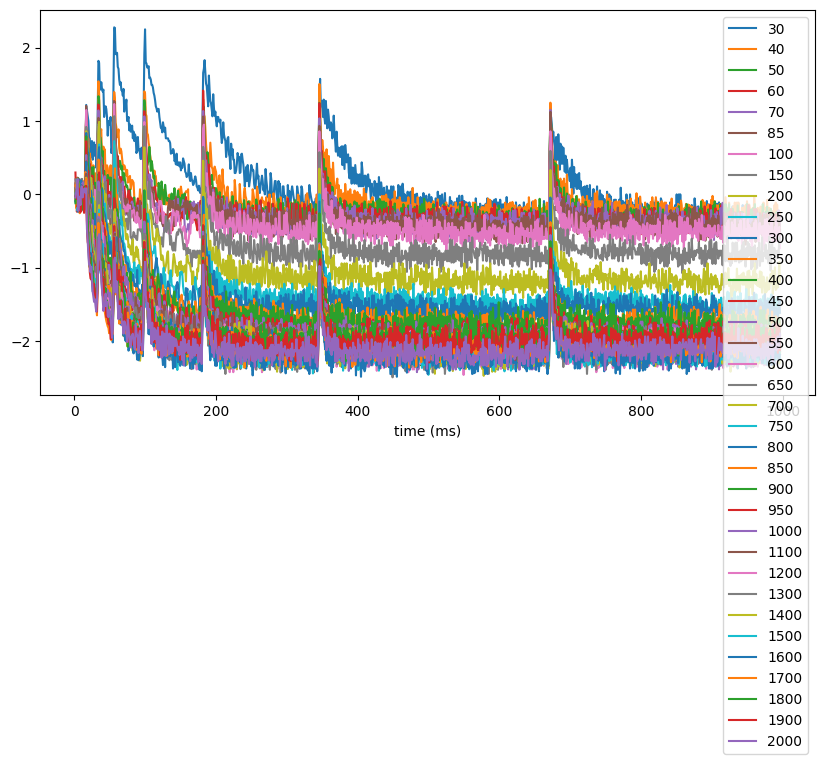

In [5]:
# t_axis_fit, results = analyze_DIRK_P700_trace(json_data, Protocol_label = "DIRK_P700_hl", remove_spike_artifacts = True, bool_show_fits="problematic")
results1 = analyze_PIRK_from_MultispeQ(json_data1,
                                    Protocol_label = "PIRK_ECS",
                                    #Protocol_label = "PIRK_P700_hl",
                                    show_abs_traces = True,
                                    #datapoints_to_use = 30,
                                    show_fits=0,
                                    use_fixed_fit_wndw_len = True
                                    )

results1.index=results1.PAR

results2 = analyze_PIRK_from_MultispeQ(json_data2,
                                    Protocol_label = "PIRK_ECS",
                                    #Protocol_label = "PIRK_P700_hl",
                                    show_abs_traces = False,
                                    #datapoints_to_use = 30,
                                    show_fits=0,
                                    use_fixed_fit_wndw_len = True
                                    )
results2.index = results2.PAR

results2

## "quickly" simulate all PIRKS with all those PARS

In [6]:
row_indexes_to_simulate = list(results1.T)

def simulate_DIRK_readouts(row_indexes_to_simulate, results, column_translations):

    df = pd.DataFrame()

    for index in tqdm(row_indexes_to_simulate):
        row = results.loc[index,:]
        protocol = row["simulation_meta_info"]
        PAR = protocol[0][1]
        s = Simulator(m)
        c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = True, input_in_ms= True, use_tqdm = False, shift_time = False, output_in_ms=True)
        result = analyse_PIRK_from_simulation(c, protocol, input_is_in_ms= True, protocol_time_is_accumulated=True, visualize_fits="", collapse_rows_to_lists = True)
        df = pd.concat([df, result], ignore_index=False)

    df = df.drop(columns = list(set(df.columns) - set(column_translations.keys()))) # get rid of everything else
    df = df.rename(columns= column_translations)
    return df
# here protocol and c.index have to have the same unit (either ms or s!)

new_names = {"PAR": "PAR",
             "ECS_tot": "amplitude",
             "ECS_b": "baseline", 
             "ECS_rate": "rate",
             "ECS_flux": "flux",
             "ECS_Rsquared": "r_squared",
             "start_time_ms": "time"}

simulated = simulate_DIRK_readouts(row_indexes_to_simulate, results1, new_names)

100%|██████████| 35/35 [07:44<00:00, 13.27s/it]


In [130]:
simulated = checkpoint("simulated", f"{model}/PIRK_replication_from_in_vivo", "simulated", overwrite=False) 

Saved: pickles/with_dpsi/PIRK_replication_from_in_vivo\simulated.joblib


In [7]:
simulated

,time,amplitude,baseline,rate,flux,r_squared
30,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[37.834997377523635, 53.30328517284139, 68.992...","[12.077481758129329, 13.008326670932776, 13.79...","[1.6653700228745043, 1.3991543776881397, 1.070...","[63.00927044806335, 74.57952479474034, 73.8501...","[0.9231880689376916, 0.9613494210618478, 0.981..."
40,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[11.828443402558133, 26.862754140075374, 35.71...","[10.119251680991558, 11.156150151855572, 11.75...","[0.9624237401829887, 2.7875140675420376, 2.507...","[11.383974740032794, 74.88030505838321, 89.551...","[0.7786262883076852, 0.8428737465792555, 0.898..."
50,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[6.893857960409807, 10.758168748930327, 24.471...","[9.297759795167224, 10.04461984421392, 10.8710...","[0.536397646544871, 0.9684868116442474, 3.3625...","[3.697849185578445, 10.419144550782315, 82.285...","[0.7776795673457497, 0.7510511652983208, 0.811..."
60,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[5.529081268835433, 6.978574380476946, 9.81270...","[8.890459623377735, 9.42809762978642, 9.952096...","[0.4417785440849109, 0.5692823373260304, 0.903...","[2.442629473073269, 3.9727791345214705, 8.8618...","[0.7957615479328775, 0.7517706624433091, 0.736..."
70,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[4.871927618201709, 5.689186087481353, 6.75214...","[8.621263700087443, 9.047089848665278, 9.39597...","[0.39649176274864467, 0.45926884791740474, 0.5...","[1.9316791693246014, 2.6128659399852885, 3.719...","[0.8119629242055295, 0.7703377148352275, 0.743..."
85,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[4.3545341138568405, 4.7718638860816025, 5.219...","[8.34262630156039, 8.682868176511187, 8.920989...","[0.3588488600789633, 0.3916189895279431, 0.426...","[1.562619602932486, 1.868752513232161, 2.22443...","[0.8302357252213605, 0.7955820397727864, 0.771..."
100,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[4.081772634023493, 4.291430145220999, 4.49895...","[8.14854304121, 8.422878085617517, 8.589025958...","[0.33646504573003966, 0.3547740336409752, 0.37...","[1.3733738159663391, 1.5224879827085298, 1.667...","[0.8428882124687908, 0.8163404681917902, 0.798..."
150,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[3.8020098857253855, 3.656254849261197, 3.5709...","[7.802594725405059, 7.931545027228163, 7.94539...","[0.2997807796872001, 0.30178584395337604, 0.30...","[1.1397694879211988, 1.103405955392914, 1.0714...","[0.8624682977126666, 0.854553333462385, 0.8532..."
200,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[3.899208272501989, 3.4990860945036393, 3.2800...","[7.698397470111811, 7.73171543407606, 7.628893...","[0.2854695346022635, 0.28394788145737887, 0.27...","[1.1131051708684387, 0.9935580835712822, 0.898...","[0.8634667237448166, 0.8668152906587336, 0.876..."
250,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[4.190376220161249, 3.532115804888677, 3.18901...","[7.734156213020403, 7.661035036360499, 7.48020...","[0.28273795924025186, 0.2725368910345461, 0.26...","[1.1847784209372718, 0.9626318602383435, 0.832...","[0.8523597108471168, 0.8705466345927196, 0.886..."


[Text(0.5, 0, 'time (ms)')]

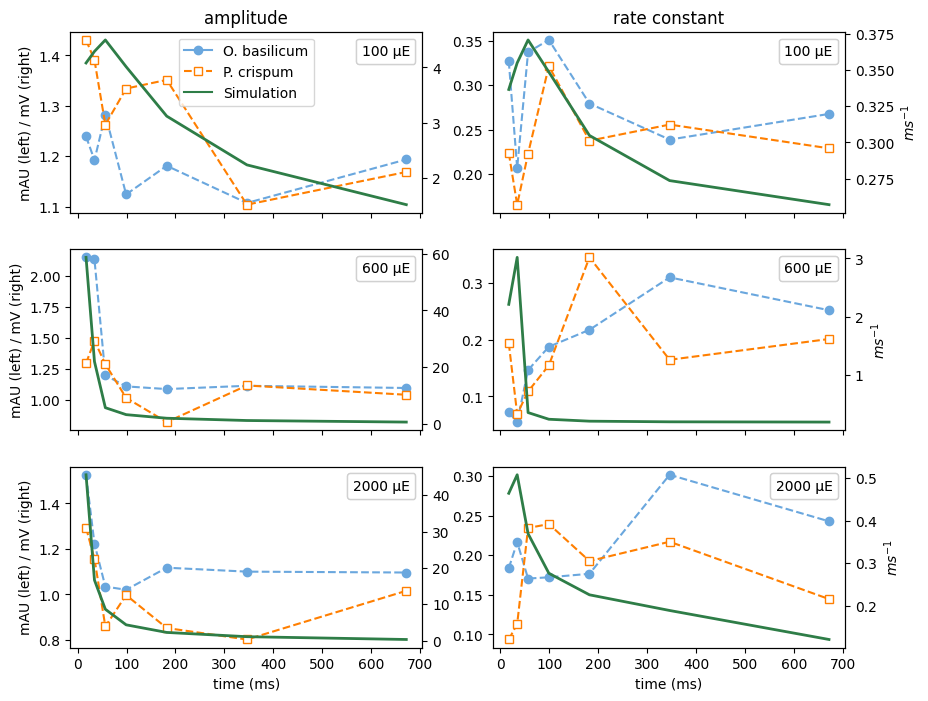

In [128]:
fig, ax = plt.subplots(3,2, figsize=(10,8))
#150,500, 1500
for row, light in enumerate([100, 600, 2000]):
    for col, thing in enumerate(["amplitude", "rate"]):
        ax2 = ax[row, col].twinx()

        time = results1.loc[light, "time"]
        ax[row, col].plot(time,  results1.loc[light, thing], label = "O. basilicum",
                          color=colors[0], marker="o", linestyle="--")
        ax[row, col].plot(time,  results2.loc[light, thing], label = "P. crispum",  
                          color=colors[1], marker="s", linestyle="--",markerfacecolor='white')
        ax2.plot(time, simulated.loc[light, thing], label = "simulation",
                            color=colors[2], linewidth = 2, linestyle="-")
        
        if col == 1: ax2.set_ylabel("$ms^{-1}$")
        if col == 0: ax[row,col].set_ylabel("mAU (left) / mV (right)")
        if row != 2: ax[row, col].set_xticklabels([])
        
        label2 = Line2D([], [], color='none', label=f"{light} µE")
        ax2.add_artist(ax2.legend(handles=[label2], loc="upper right", bbox_to_anchor = (1,1), handlelength=0, handletextpad=0))

species_handles  = [
    Line2D([0], [0], label="O. basilicum", color=colors[0], marker="o", linestyle="-"),
    Line2D([0], [0], label="P. crispum",   color=colors[1], marker="s", linestyle="--", markerfacecolor='white'),
    Line2D([0], [0], label="Simulation",   color=colors[2], linestyle="-")
]
legend_species = ax[0,0].legend(handles=species_handles, loc="upper center")

ax[0,0].set(title = "amplitude")
ax[0,1].set(title = "rate constant")
ax[2,0].set(xlabel = "time (ms)")
ax[2,1].set(xlabel = "time (ms)")

In [121]:
save_fig(fig, "in_vivo", "analysis", f"PIRK_ECS_in_vivo_analysis_rate_amplitude_three_plot")

existing figure backed up to figures/in_vivo/analysis/Z_backup_PIRK_ECS_in_vivo_analysis_rate_amplitude_three_plot.png
saved figure to figures/in_vivo/analysis/PIRK_ECS_in_vivo_analysis_rate_amplitude_three_plot.png


[Text(0.5, 0, 'time (ms)')]

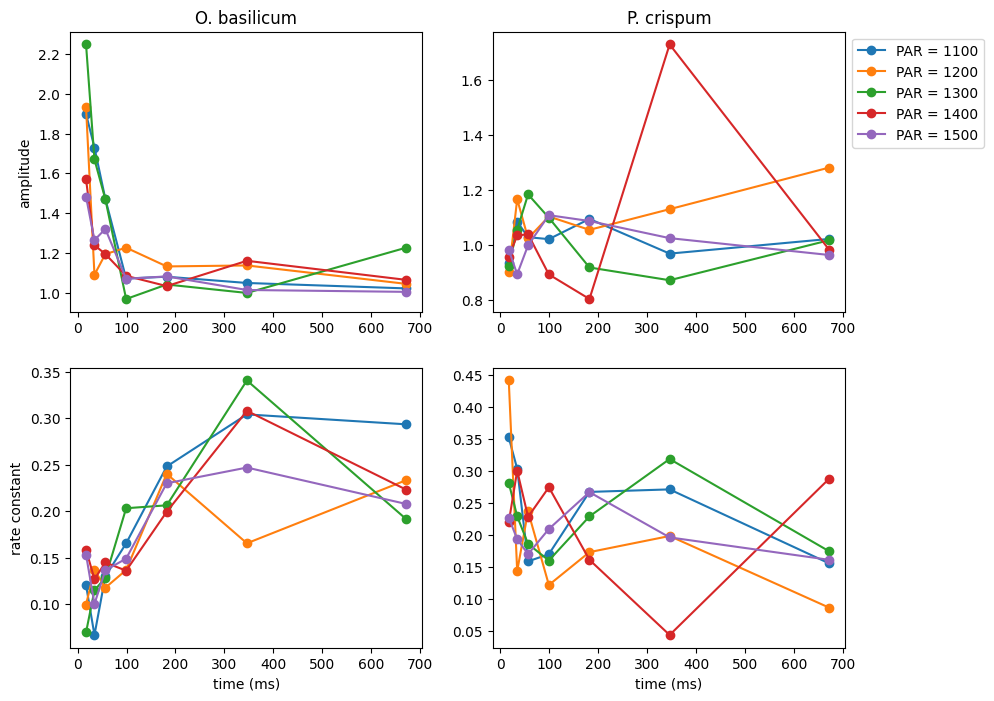

In [125]:
fig, ax = plt.subplots(2,2, figsize=(10,8))

for row, thing in enumerate(["amplitude", "rate"]):
    for col, organism in enumerate([results1, results2]):

        time = results1.loc[light, "time"]
        results = organism
        
        for idx in results.index[25:30:]:
            trace = results.loc[idx,thing]
            ax[row, col].plot(results.loc[idx, "time"][0:], trace[0:], label = f"PAR = {results.loc[idx, 'PAR']}", marker = "o")
        
        # if col == 1: ax2.set_ylabel("$ms^{-1}$")
        # if col == 0: ax[row,col].set_ylabel("mAU (left) / mV (right)")
        # if row != 2: ax[row, col].set_xticklabels([])
        
        # label2 = Line2D([], [], color='none', label=f"{light} µE")
        # ax2.add_artist(ax2.legend(handles=[label2], loc="upper right", bbox_to_anchor = (1,1), handlelength=0, handletextpad=0))

ax[0,0].set(title = "O. basilicum",
            ylabel = "amplitude")
ax[0,1].set(title = "P. crispum")
ax[0,1].legend(loc = "upper left", bbox_to_anchor = (1,1))
ax[1,0].set(xlabel = "time (ms)",
            ylabel = "rate constant")
ax[1,1].set(xlabel = "time (ms)")

In [119]:
save_fig(fig, "in_vivo", "analysis", f"PIRK_ECS_in_vivo_analysis_pooled_plot")

existing figure backed up to figures/in_vivo/analysis/Z_backup_PIRK_ECS_in_vivo_analysis_pooled_plot.png
saved figure to figures/in_vivo/analysis/PIRK_ECS_in_vivo_analysis_pooled_plot.png


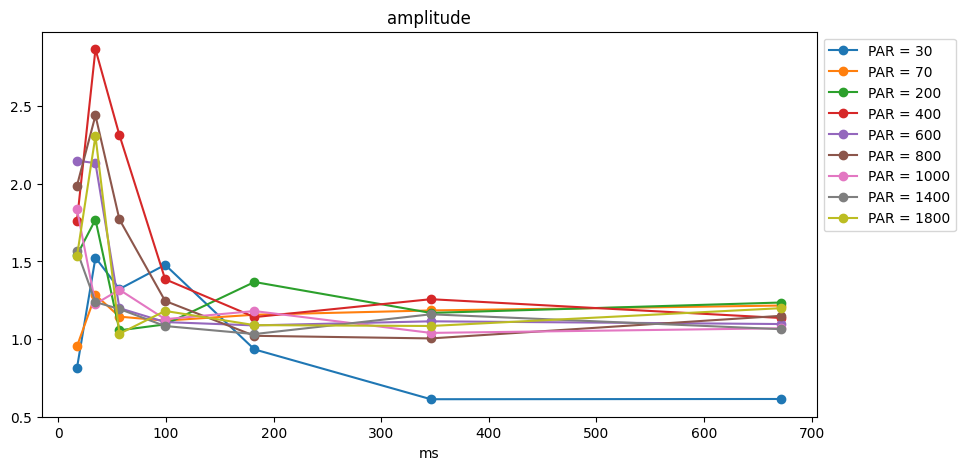

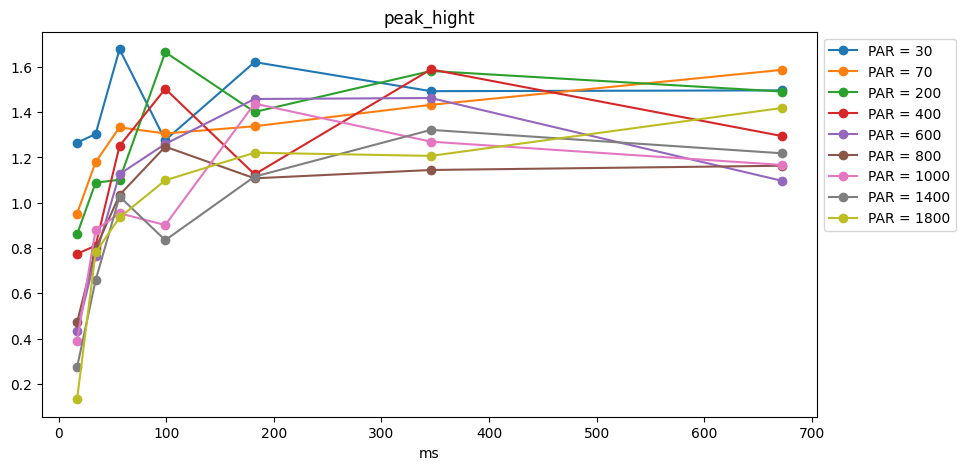

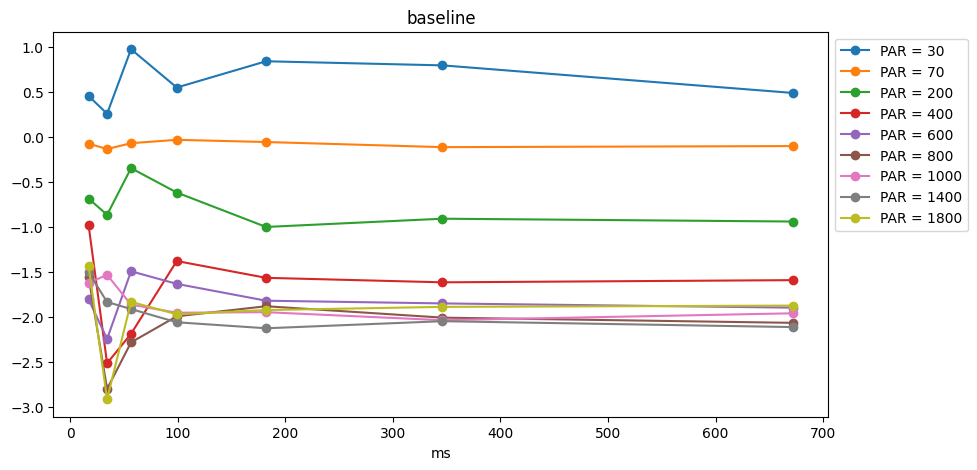

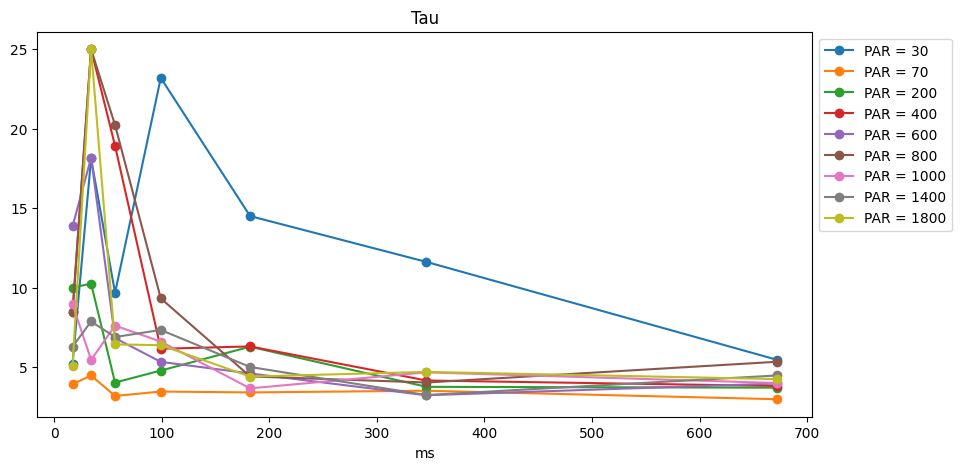

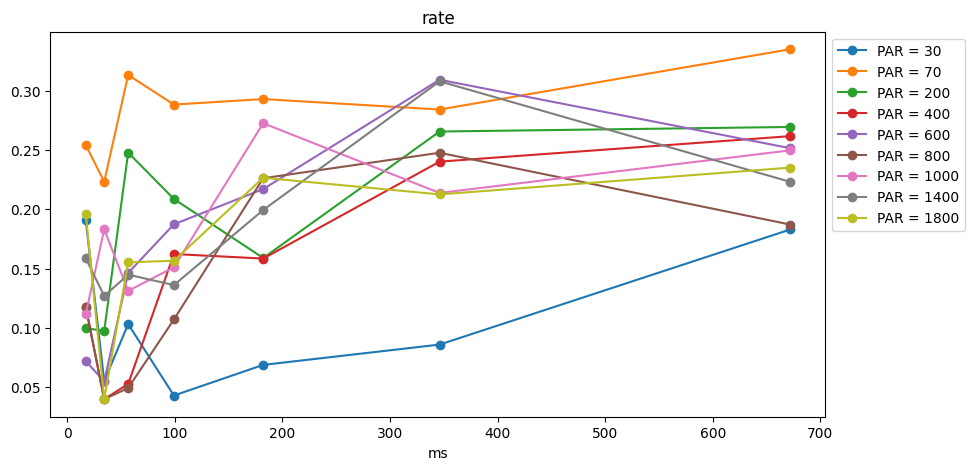

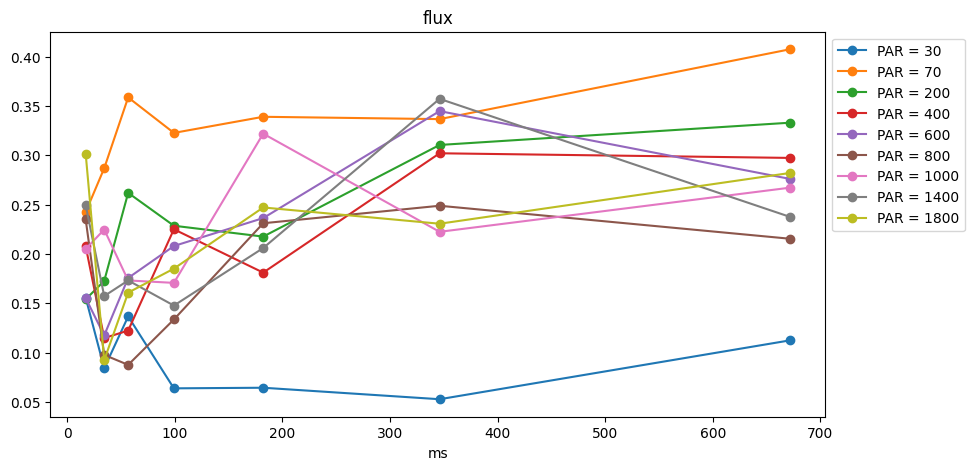

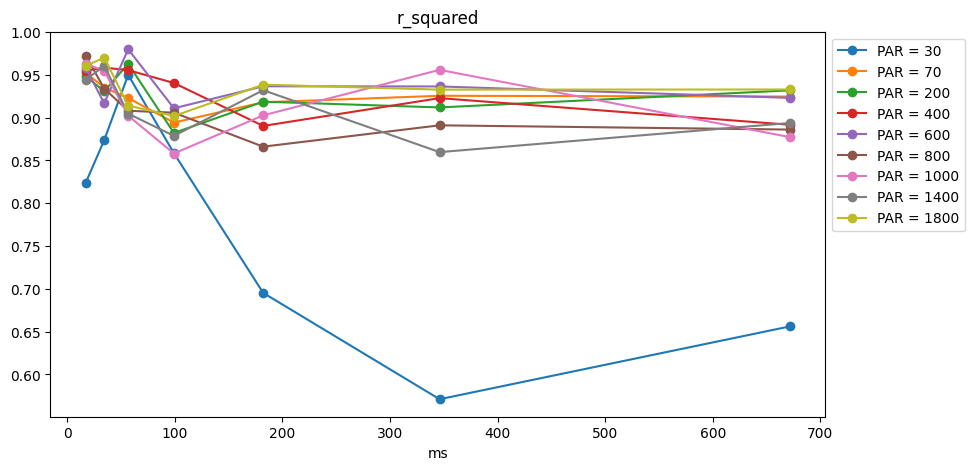

In [97]:
results = results1

results["PAR"] = simulated.index

for readout in results.columns.drop(["PAR", "traces", "time", "simulation_meta_info"], errors = "ignore"):
    fig, ax = plt.subplots(1,1,figsize=(10,5))
    for idx in results.index[0:34:4]:
        trace = results.loc[idx,readout]
        ax.plot(results.loc[idx, "time"][0:], trace[0:], label = f"PAR = {results.loc[idx, 'PAR']}", marker = "o")
    ax.set(title= readout,
           xlabel= "ms",
           #xscale = "log"
           )
    ax.legend(loc = "upper left", bbox_to_anchor = (1,1))